In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from datetime import datetime
import os


In [3]:
acled_data = pd.read_csv('../../data/raw/features/ACLED_2018.csv')
ml_targets = pd.read_csv("../../data/processed/sl_ml_targets_2025-10-06.csv")
hh_info = pd.read_csv("../../data/processed/hh_info.csv")
adm2_average = pd.read_csv("../../data/processed/adm2_average.csv")

In [4]:
ml_targets


,iso3,survey,hhid,vita_rae_mcg,folate_mcg,vitb12_mcg,fe_mg,zn_mg,overall_mar
0,LKA,lka_hies19,11100111,141.771251,203.900155,0.664669,10.511153,7.443397,0.594869
1,LKA,lka_hies19,11100121,156.913148,294.643247,2.095717,16.224352,12.205733,0.864046
2,LKA,lka_hies19,11100131,129.687786,157.913889,0.570306,15.480044,9.110118,0.636296
3,LKA,lka_hies19,11100141,68.646014,155.070328,1.249101,7.259847,4.729379,0.480061
4,LKA,lka_hies19,11100151,199.522686,204.118187,1.003891,10.476471,8.111925,0.667098
...,...,...,...,...,...,...,...,...,...
19906,LKA,lka_hies19,19208551,66.503481,169.805471,0.792777,9.284953,9.448862,0.566066
19907,LKA,lka_hies19,19208561,126.022109,202.143046,0.979918,12.717502,11.817528,0.680711
19908,LKA,lka_hies19,19208571,107.433567,108.421219,0.560491,8.051044,7.167088,0.455042
19909,LKA,lka_hies19,19208581,81.682584,150.781143,1.035865,9.860609,10.237976,0.589026


In [5]:
acled_data['event_date'] = pd.to_datetime(acled_data['event_date'], format='%Y-%m-%d')
acled_data['event_month'] = acled_data['event_date'].dt.month
acled_data
# count the number of events per month 
# acled_data.groupby('event_month')
acled_counts2018 = acled_data[['event_month','admin2']].value_counts()
acled_counts2018 = pd.DataFrame(acled_counts2018).reset_index()
acled_counts2018

acled_counts2018_noseason = acled_data[['admin2']].value_counts()
acled_counts2018_noseason = pd.DataFrame(acled_counts2018_noseason).reset_index()
acled_counts2018_noseason

,admin2,count
0,Colombo,156
1,Jaffna,30
2,Nuwara Eliya,27
3,Hambantota,21
4,Kandy,20
5,Puttalam,17
6,Gampaha,14
7,Batticaloa,13
8,Anuradhapura,12
9,Kilinochchi,11


In [6]:
# look at types of acled variable
 
acled_data['interaction'].unique()
acled_data['admin2'].unique()

array(['Nuwara Eliya', 'Colombo', 'Mannar', 'Hambantota', 'Vavuniya', 'Kegalle', 'Moneragala', 'Badulla', 'Anuradhapura',
       'Galle', 'Jaffna', 'Kalutara', 'Batticaloa', 'Gampaha', 'Puttalam', 'Kandy', 'Kilinochchi', 'Matara', 'Matale',
       'Mullaitivu', 'Ratnapura', 'Kurunegala', 'Polonnaruwa', 'Trincomalee', 'Ampara'], dtype=object)

In [7]:

def merge_district_codes(df):
    # District code mapping
    districts = [
        {"adm2": 81, "admin2": "Badulla"}, {"adm2": 11, "admin2": "Colombo"},
        {"adm2": 12, "admin2": "Gampaha"}, {"adm2": 41, "admin2": "Jaffna"},
        {"adm2": 13, "admin2": "Kalutara"}, {"adm2": 21, "admin2": "Kandy"},
        {"adm2": 92, "admin2": "Kegalle"}, {"adm2": 61, "admin2": "Kurunegala"},
        {"adm2": 43, "admin2": "Mannar"}, {"adm2": 22, "admin2": "Matale"},
        {"adm2": 82, "admin2": "Moneragala"}, {"adm2": 23, "admin2": "Nuwara Eliya"},
        {"adm2": 72, "admin2": "Polonnaruwa"}, {"adm2": 91, "admin2": "Ratnapura"},
        {"adm2": 53, "admin2": "Trincomalee"}, {"adm2": 44, "admin2": "Vavuniya"},
        {"adm2": 71, "admin2": "Anuradhapura"}, {"adm2": 44, "admin2": "Mullaitivu"},
        {"adm2": 52, "admin2": "Ampara"},{"adm2":52, "admin2": "Batticaloa"},
        {"adm2": 33, "admin2": "Hambantota"}, {"adm2": 45, "admin2": "Kilinochchi"},
        {"adm2": 62, "admin2": "Puttalam"}, {"adm2": 31, "admin2": "Galle"},
        {"adm2": 32, "admin2": "Matara"}
        
    ]
    
    df_districts = pd.DataFrame(districts)
    
    # Merge to assign adm2 codes
    merged = df.merge(df_districts, on='admin2', how='left')
    
    return merged


matched_data = merge_district_codes(acled_counts2018)

matched_data

acled_counts2018_noseason = merge_district_codes(acled_counts2018_noseason)



In [8]:
matched_data_hm = matched_data.pivot(index="event_month", columns="admin2", values="count").fillna(0)

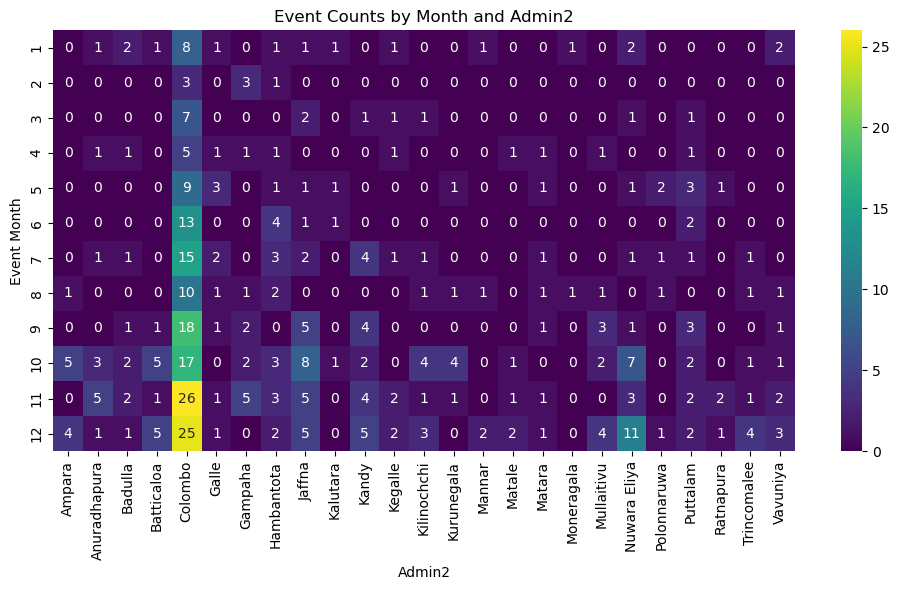

In [9]:


plt.figure(figsize=(10, 6))
sns.heatmap(matched_data_hm, cmap="viridis", annot=True, fmt=".0f")
plt.title("Event Counts by Month and Admin2")
plt.xlabel("Admin2")
plt.ylabel("Event Month")
plt.tight_layout()
plt.show()



In [10]:
hh_info = hh_info[["hhid",'adm2', 'month']]


ml_targets = ml_targets.merge(hh_info)
ml_targets

ml_targets_agg = ml_targets.groupby(["adm2", "month"]).agg({
        'folate_mcg': 'median',
        'fe_mg': 'median',
        'zn_mg': 'median',
        'vita_rae_mcg':'median',
        'overall_mar': 'median'
    }).reset_index()


In [11]:
ml_targets


,iso3,survey,hhid,vita_rae_mcg,folate_mcg,vitb12_mcg,fe_mg,zn_mg,overall_mar,adm2,month
0,LKA,lka_hies19,11100111,141.771251,203.900155,0.664669,10.511153,7.443397,0.594869,11,1
1,LKA,lka_hies19,11100121,156.913148,294.643247,2.095717,16.224352,12.205733,0.864046,11,1
2,LKA,lka_hies19,11100131,129.687786,157.913889,0.570306,15.480044,9.110118,0.636296,11,1
3,LKA,lka_hies19,11100141,68.646014,155.070328,1.249101,7.259847,4.729379,0.480061,11,1
4,LKA,lka_hies19,11100151,199.522686,204.118187,1.003891,10.476471,8.111925,0.667098,11,1
...,...,...,...,...,...,...,...,...,...,...,...
19906,LKA,lka_hies19,19208551,66.503481,169.805471,0.792777,9.284953,9.448862,0.566066,92,12
19907,LKA,lka_hies19,19208561,126.022109,202.143046,0.979918,12.717502,11.817528,0.680711,92,12
19908,LKA,lka_hies19,19208571,107.433567,108.421219,0.560491,8.051044,7.167088,0.455042,92,12
19909,LKA,lka_hies19,19208581,81.682584,150.781143,1.035865,9.860609,10.237976,0.589026,92,12


In [12]:
matched_data.rename(columns={'event_month': 'month'}, inplace=True)
matched_data
adm2_season = ml_targets_agg.merge(matched_data, on= ['adm2','month'])
adm2_season
adm2_total= ml_targets_agg.merge(matched_data, on= ['adm2'])

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


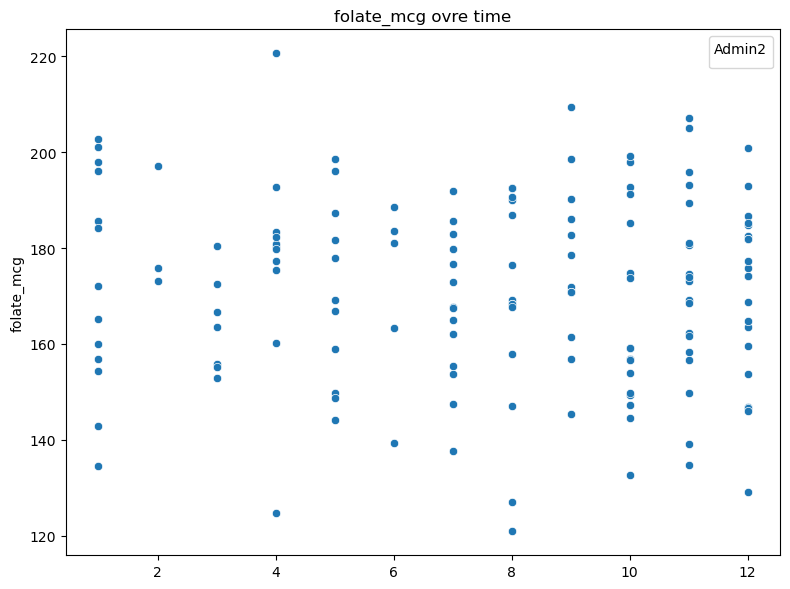

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


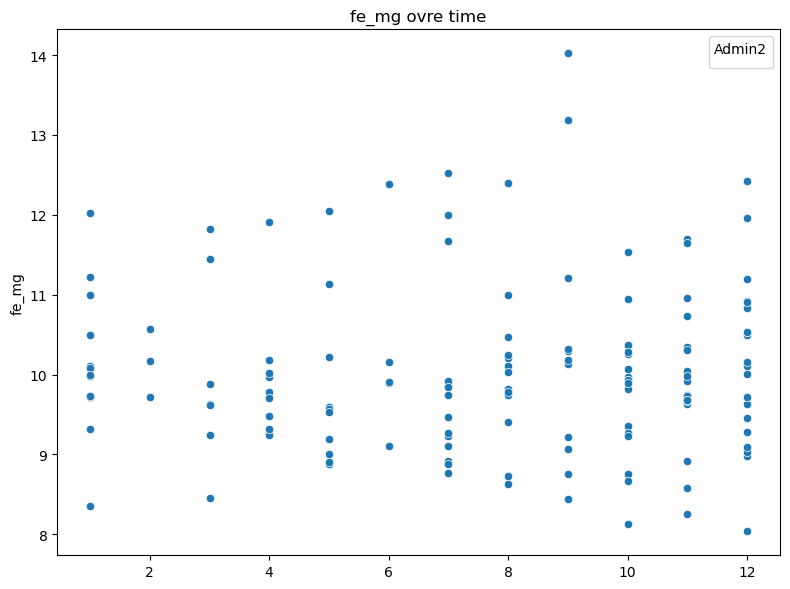

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


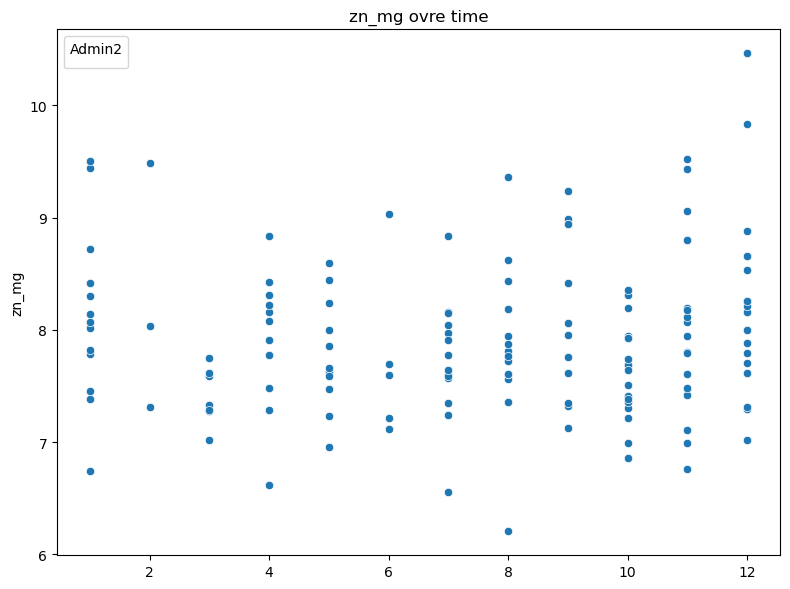

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


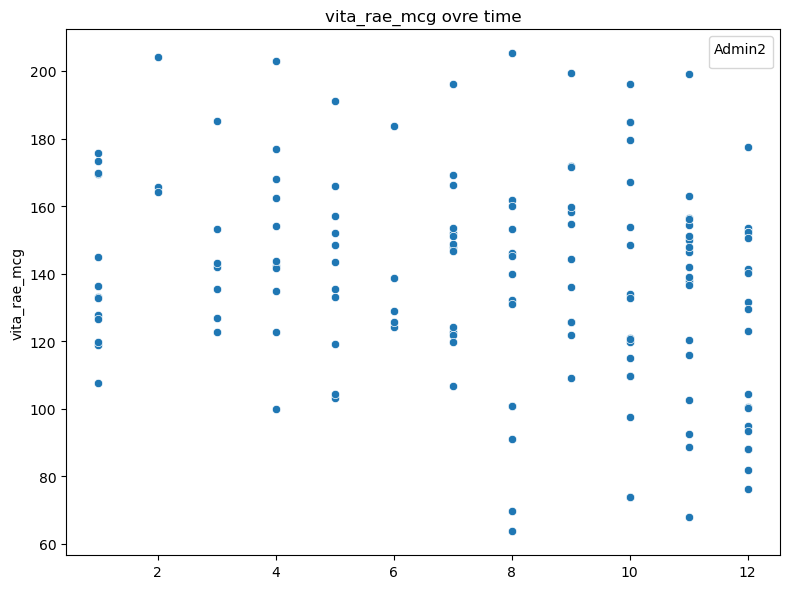

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


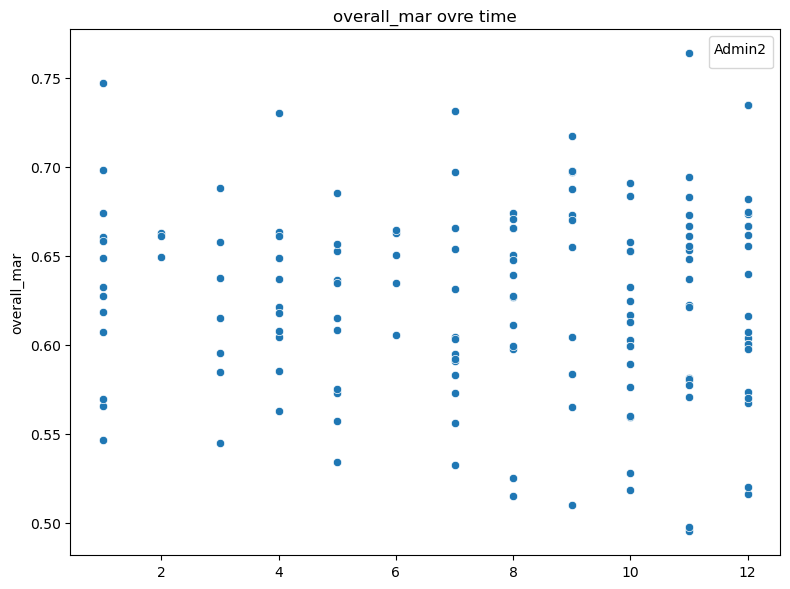

In [13]:


# List of nutrients to plot
nutrients = ['folate_mcg', 'fe_mg', 'zn_mg','vita_rae_mcg', 'overall_mar']

# Loop through each nutrient and create a scatter plot
for nutrient in nutrients:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=adm2_season, x='month', y=nutrient)
 
    # sns.lineplot(data=adm2_season, x='month', y=nutrient,
    # #  hue='admin2',
    #   marker = 'o')
    plt.title(f'{nutrient} ovre time')
    plt.xlabel('')
    plt.ylabel(nutrient)
    plt.legend(title='Admin2')
    plt.tight_layout()
    plt.show()



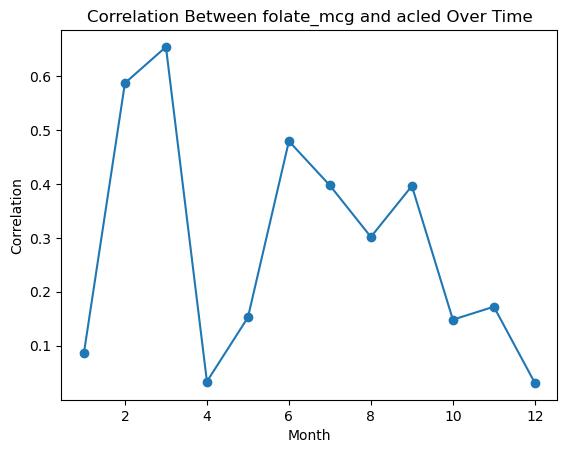

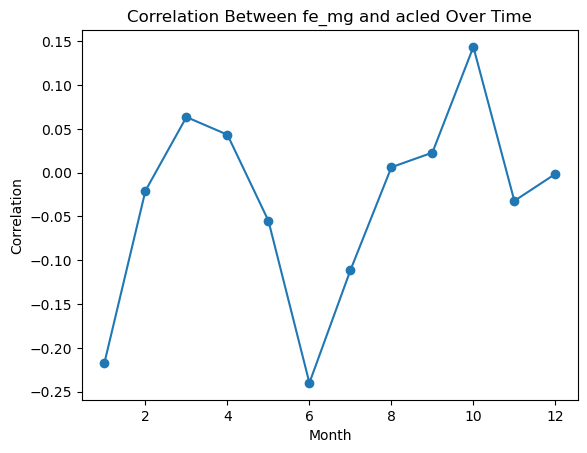

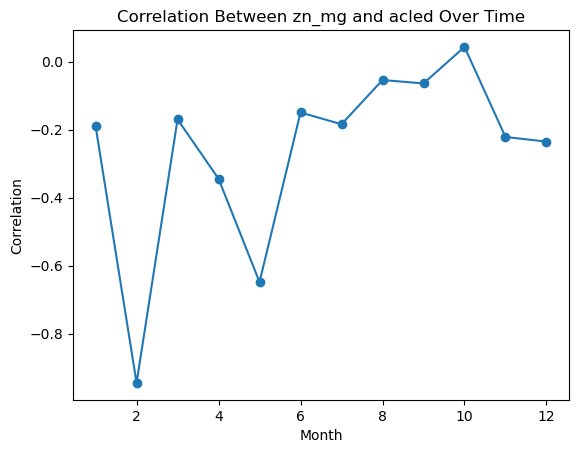

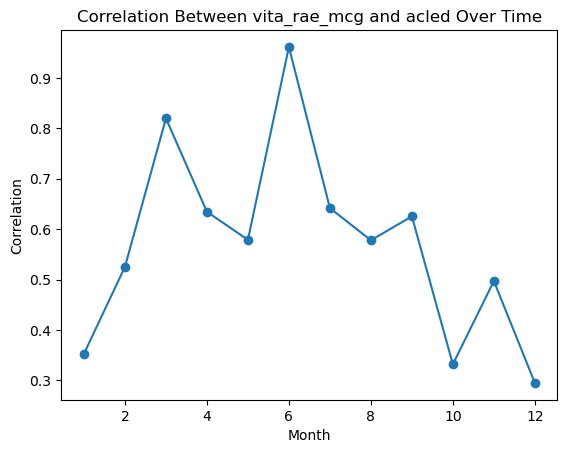

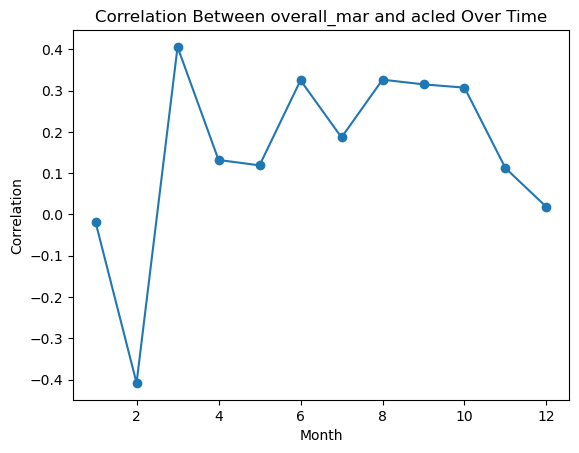

In [14]:
for nutrient in nutrients:
    corr_by_month = adm2_season.groupby('month')[[nutrient, 'count']].corr().unstack().iloc[:,1]
    corr_by_month.plot(kind='line', marker='o')
    plt.title(f'Correlation Between {nutrient} and acled Over Time')
    plt.xlabel('Month')
    plt.ylabel('Correlation')
    plt.show()


Look at household level for ACLED

In [15]:

matched_data.rename(columns={'event_month': 'month'}, inplace=True)
matched_data
adm2_season_hh = ml_targets.merge(matched_data, on= ['adm2','month'])
adm2_season_hh


,iso3,survey,hhid,vita_rae_mcg,folate_mcg,vitb12_mcg,fe_mg,zn_mg,overall_mar,adm2,month,admin2,count
0,LKA,lka_hies19,11100111,141.771251,203.900155,0.664669,10.511153,7.443397,0.594869,11,1,Colombo,8
1,LKA,lka_hies19,11100121,156.913148,294.643247,2.095717,16.224352,12.205733,0.864046,11,1,Colombo,8
2,LKA,lka_hies19,11100131,129.687786,157.913889,0.570306,15.480044,9.110118,0.636296,11,1,Colombo,8
3,LKA,lka_hies19,11100141,68.646014,155.070328,1.249101,7.259847,4.729379,0.480061,11,1,Colombo,8
4,LKA,lka_hies19,11100151,199.522686,204.118187,1.003891,10.476471,8.111925,0.667098,11,1,Colombo,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10499,LKA,lka_hies19,19208551,66.503481,169.805471,0.792777,9.284953,9.448862,0.566066,92,12,Kegalle,2
10500,LKA,lka_hies19,19208561,126.022109,202.143046,0.979918,12.717502,11.817528,0.680711,92,12,Kegalle,2
10501,LKA,lka_hies19,19208571,107.433567,108.421219,0.560491,8.051044,7.167088,0.455042,92,12,Kegalle,2
10502,LKA,lka_hies19,19208581,81.682584,150.781143,1.035865,9.860609,10.237976,0.589026,92,12,Kegalle,2


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


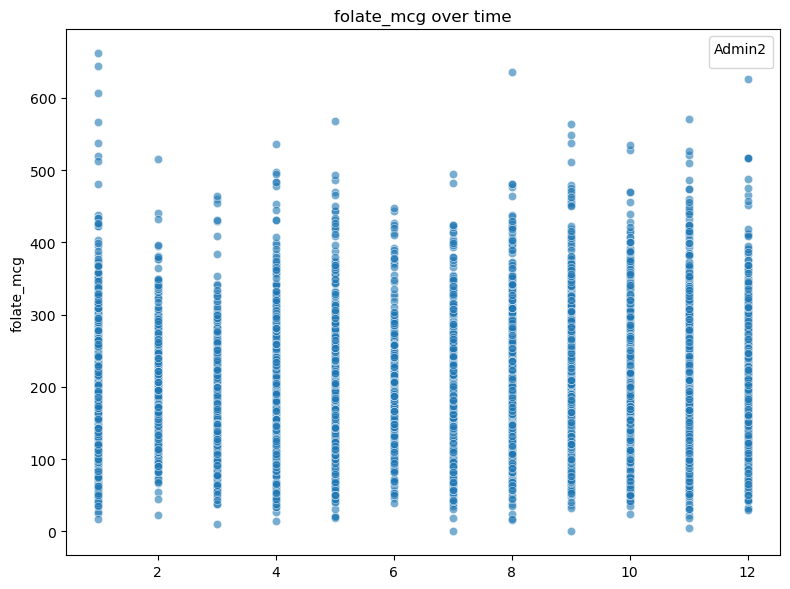

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


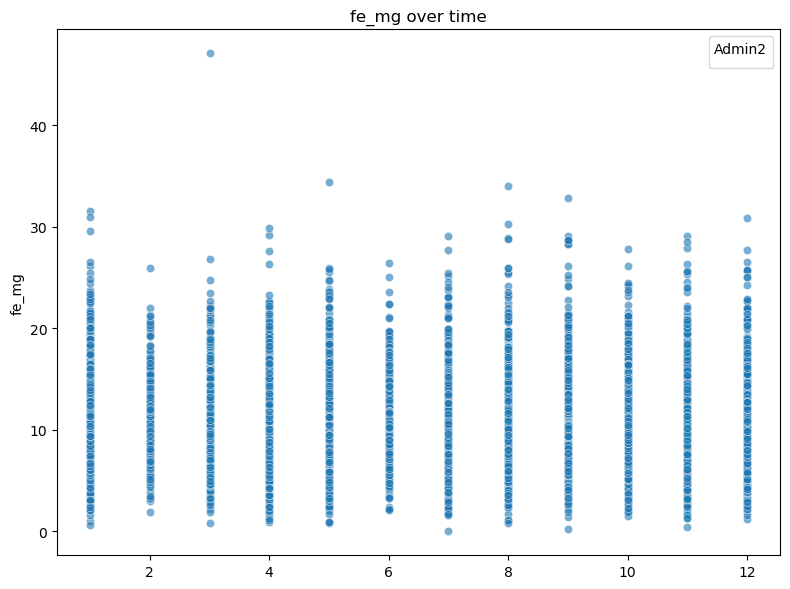

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


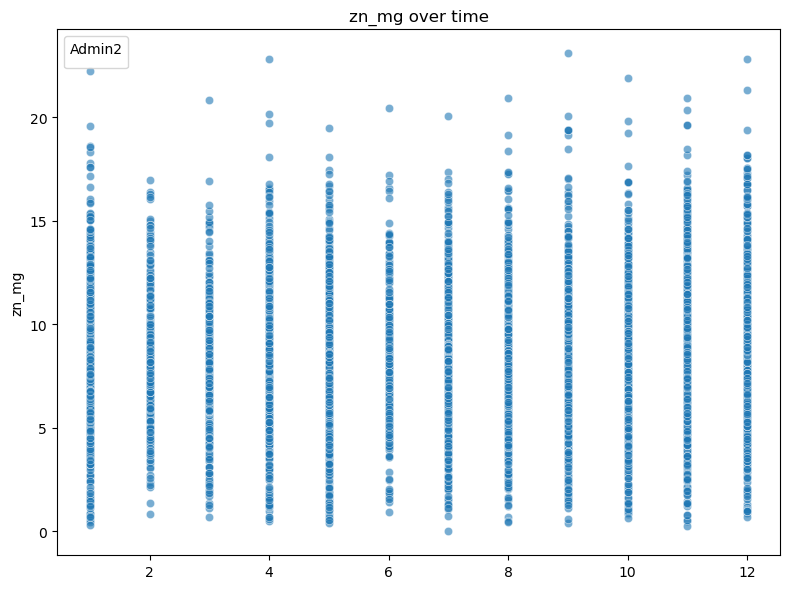

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


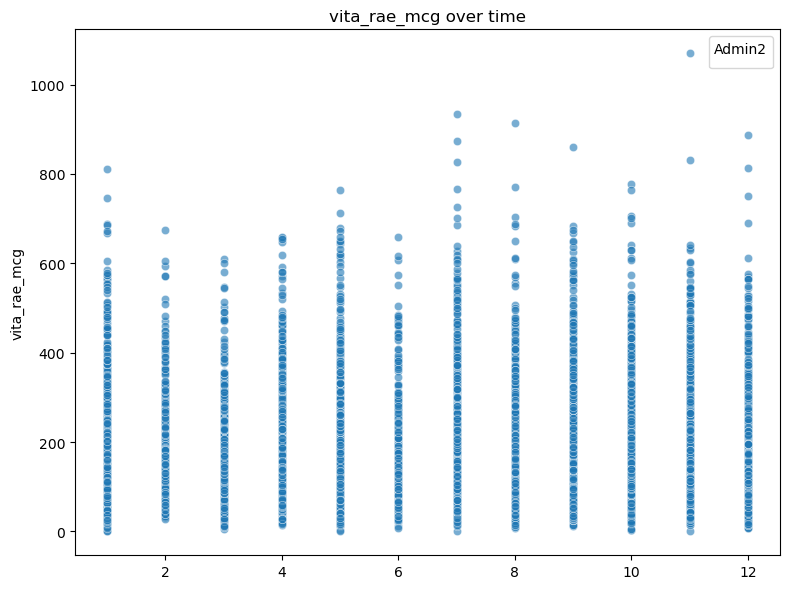

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


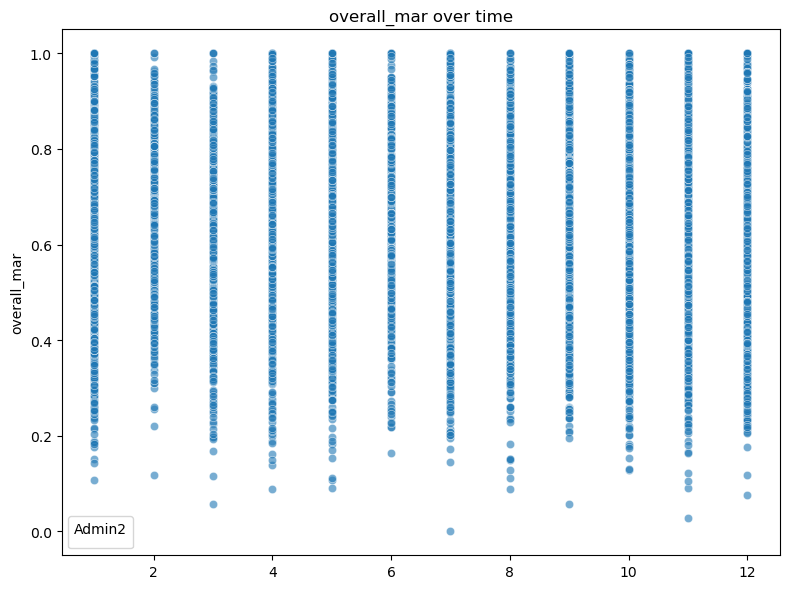

In [16]:
# List of nutrients to plot
nutrients = ['folate_mcg', 'fe_mg', 'zn_mg','vita_rae_mcg', 'overall_mar']

# Loop through each nutrient and create a scatter plot
for nutrient in nutrients:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=adm2_season_hh, x='month', y=nutrient,
    #  hue='admin2',
      marker = 'o', alpha = 0.6)
    plt.title(f'{nutrient} over time')
    plt.xlabel('')
    plt.ylabel(nutrient)
    plt.legend(title='Admin2')
    plt.tight_layout()
    plt.show()

acled_counts2018_noseason

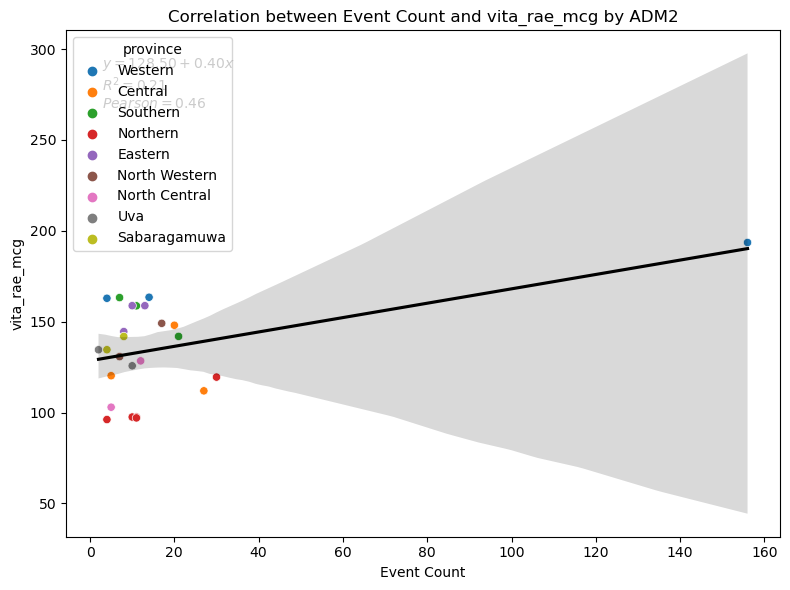

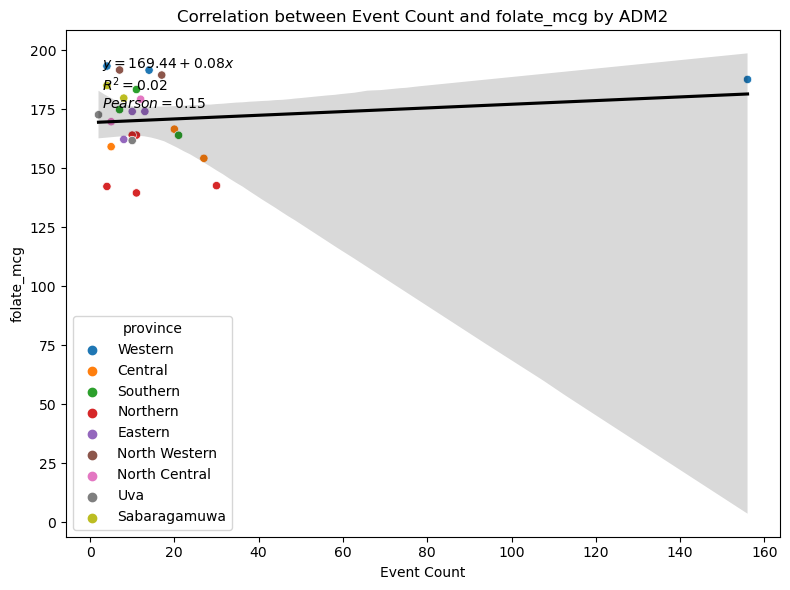

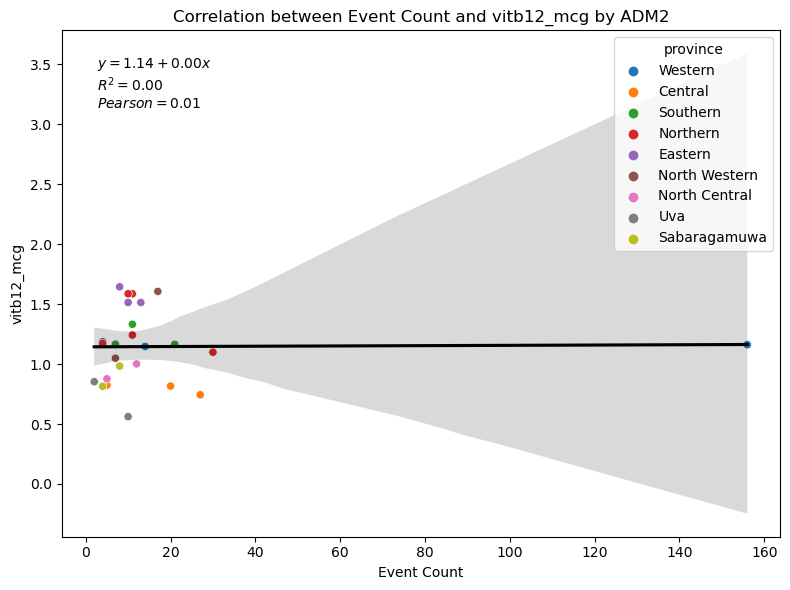

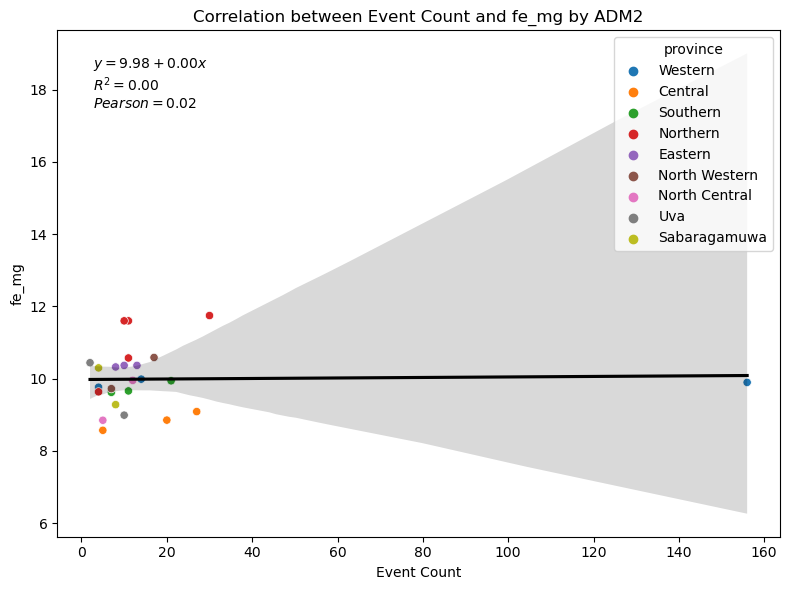

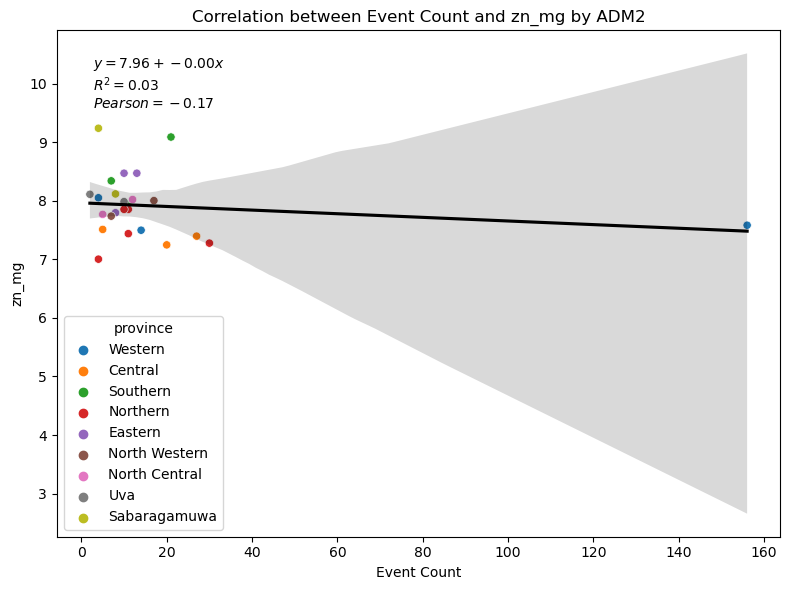

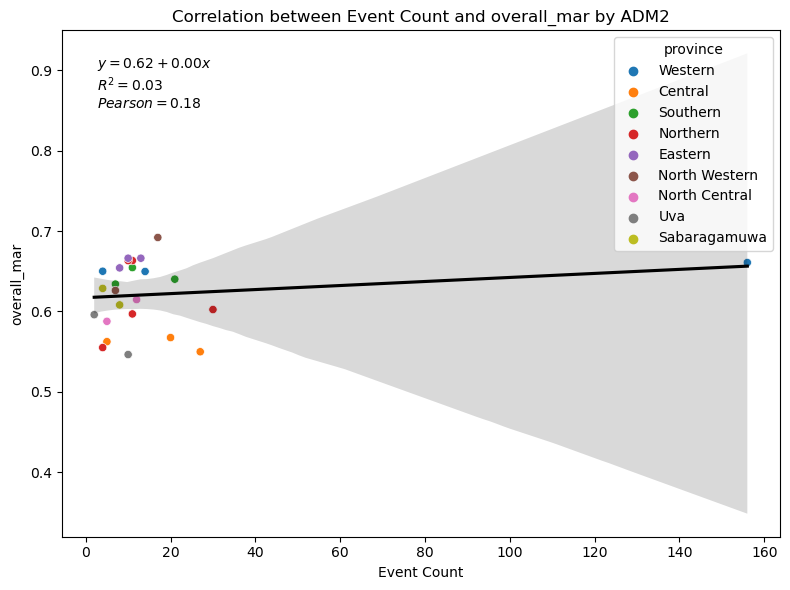

In [22]:

# Merge the data
adm2_counts = adm2_season_hh[['hhid','adm2','vita_rae_mcg','folate_mcg','vitb12_mcg','fe_mg','zn_mg','overall_mar']] \
    .groupby('adm2').agg({
        'vita_rae_mcg':'median',
         'folate_mcg':'median',
         	'vitb12_mcg':'median',	'fe_mg':'median',	'zn_mg':'median',
            'overall_mar':'median'
    }).reset_index().merge(acled_counts2018_noseason, on='adm2')

# Pivot the data
province_map = {
    1: "Western", 2: "Central", 3: "Southern", 4: "Northern", 5: "Eastern",
    6: "North Western", 7: "North Central", 8: "Uva", 9: "Sabaragamuwa"
}
adm2_counts['province'] = (adm2_counts['adm2'] // 10).round().map(province_map)

mn_col_names = list(['vita_rae_mcg', 'folate_mcg', 'vitb12_mcg', 'fe_mg', 'zn_mg', 'overall_mar'])
for i in mn_col_names:

    X = sm.add_constant(adm2_counts['count'])
    y = adm2_counts[i]

    # Combine X and y into a single DataFrame for cleaning
    data = pd.concat([X, y], axis=1)

    # Remove rows with NaN or inf values
    data_clean = data.replace([np.inf, -np.inf], np.nan).dropna()

    # Separate cleaned X and y
    X_clean = data_clean.iloc[:, :-1]
    y_clean = data_clean.iloc[:, -1]

    # Fit the model
    model = sm.OLS(y_clean, X_clean).fit()

    r_squared = model.rsquared
    intercept, slope = model.params

    pearson_r = model.params[1] / abs(model.params[1]) * r_squared**0.5

    # Annotate with R² and equation
    eq_label = f"$y = {intercept:.2f} + {slope:.2f}x$\n$R^2 = {r_squared:.2f}$\n$Pearson = {pearson_r:.2f}$"

    plt.figure(figsize=(8,6))
    sns.scatterplot(data=adm2_counts, x='count', y=i, hue='province', )
    plt.text(0.05, 0.95, eq_label, transform=plt.gca().transAxes,
                 verticalalignment='top', horizontalalignment='left', fontsize=10)

    sns.regplot(data=adm2_counts, x='count', y=i, scatter=False, color='black')
    plt.title(f"Correlation between Event Count and {i} by ADM2")
    plt.xlabel("Event Count")
    plt.ylabel(f"{i}")
    plt.tight_layout()
    plt.show()



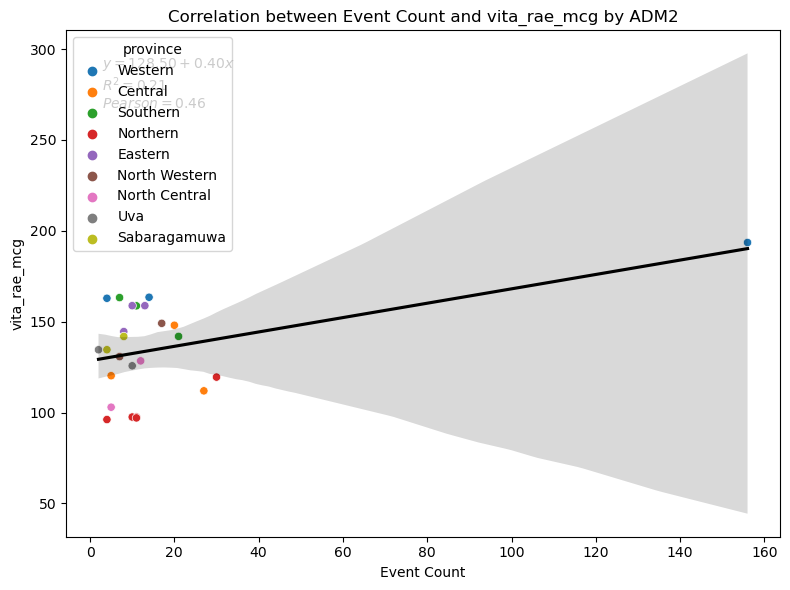

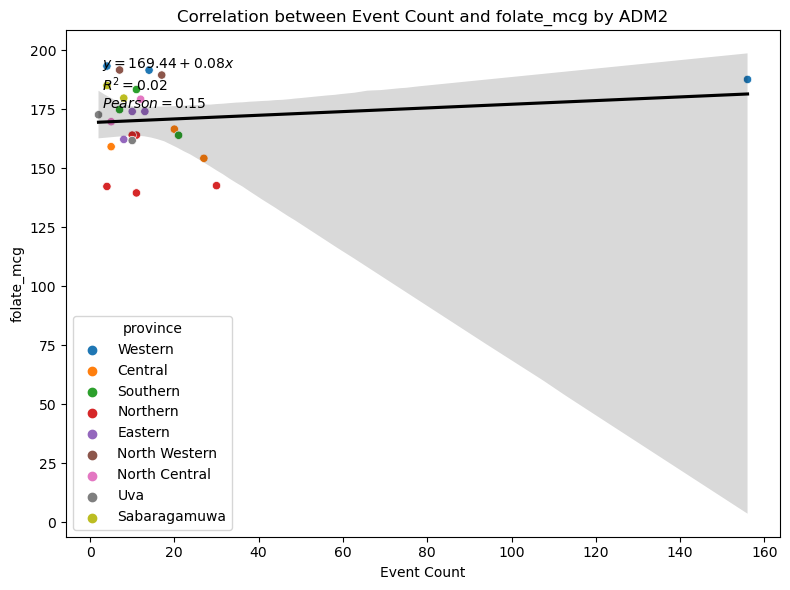

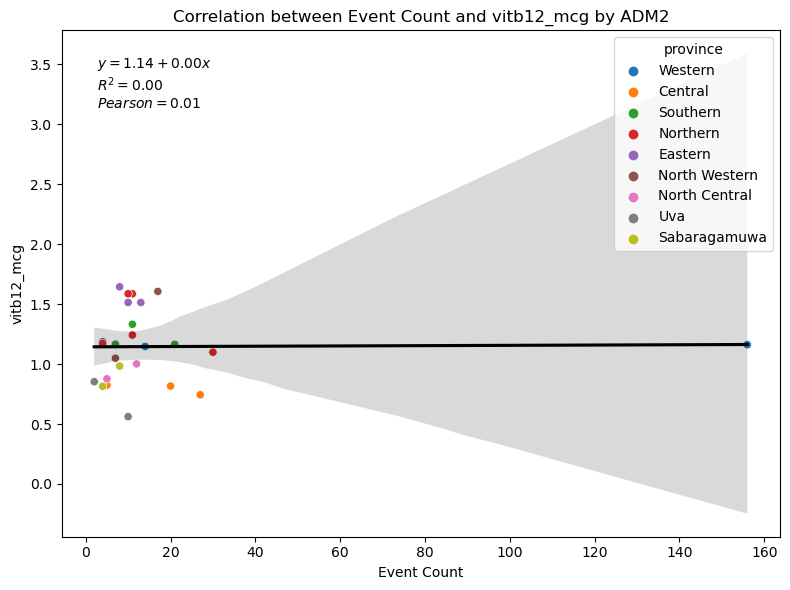

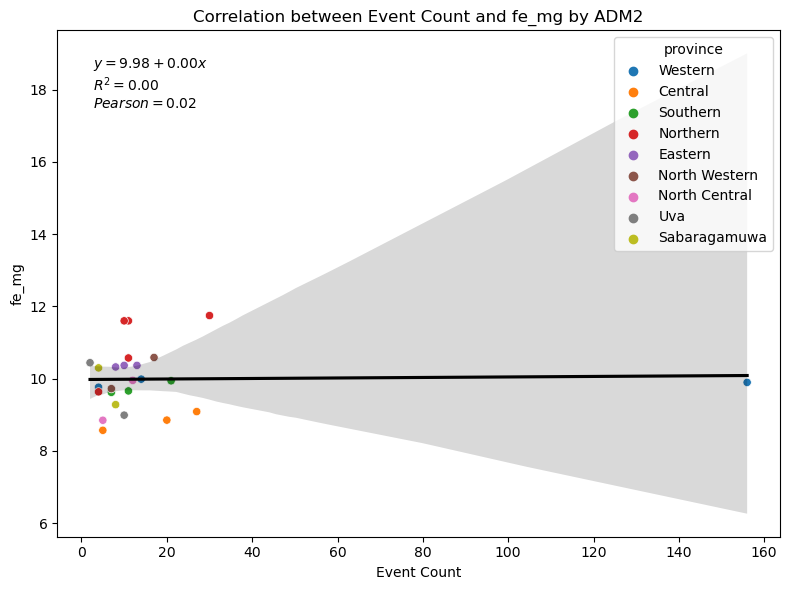

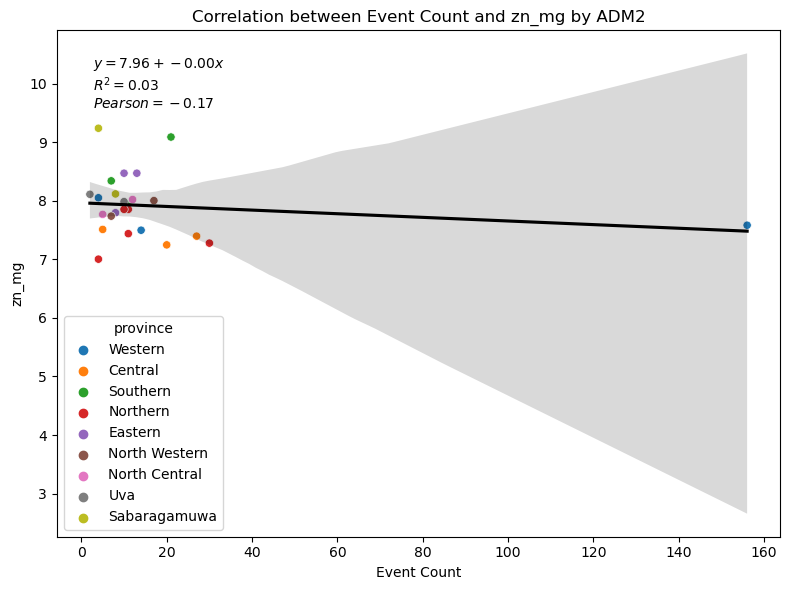

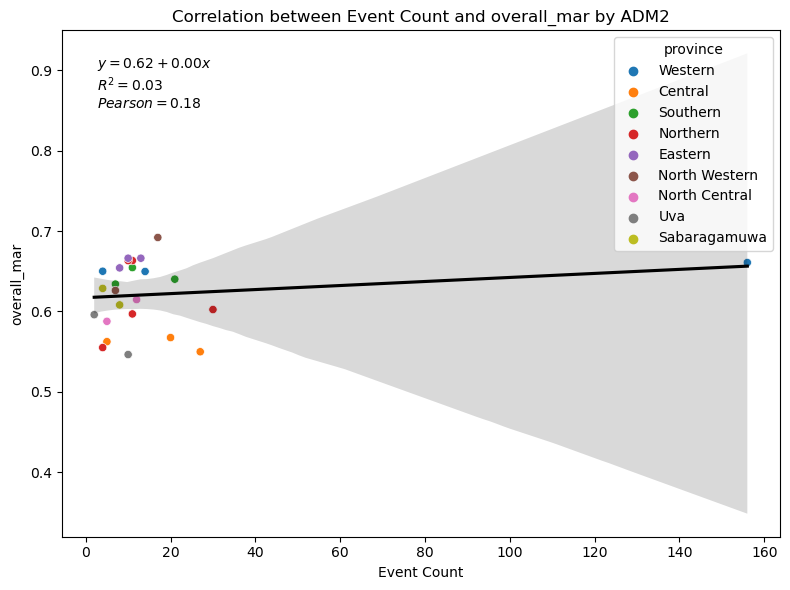

In [ ]:

# Merge the data
adm2_counts = adm2_season_hh[['hhid','adm2','vita_rae_mcg','folate_mcg','vitb12_mcg','fe_mg','zn_mg','overall_mar']] \
    .groupby('adm2').agg({
        'vita_rae_mcg':'median',
         'folate_mcg':'median',
         	'vitb12_mcg':'median',	'fe_mg':'median',	'zn_mg':'median',
            'overall_mar':'median'
    }).reset_index().merge(acled_counts2018_noseason, on='adm2')

# Pivot the data
province_map = {
    1: "Western", 2: "Central", 3: "Southern", 4: "Northern", 5: "Eastern",
    6: "North Western", 7: "North Central", 8: "Uva", 9: "Sabaragamuwa"
}
adm2_counts['province'] = (adm2_counts['adm2'] // 10).round().map(province_map)

mn_col_names = list(['vita_rae_mcg', 'folate_mcg', 'vitb12_mcg', 'fe_mg', 'zn_mg', 'overall_mar'])
for i in mn_col_names:

    X = sm.add_constant(adm2_counts['count'])
    y = adm2_counts[i]

    # Combine X and y into a single DataFrame for cleaning
    data = pd.concat([X, y], axis=1)

    # Remove rows with NaN or inf values
    data_clean = data.replace([np.inf, -np.inf], np.nan).dropna()

    # Separate cleaned X and y
    X_clean = data_clean.iloc[:, :-1]
    y_clean = data_clean.iloc[:, -1]

    # Fit the model
    model = sm.OLS(y_clean, X_clean).fit()

    r_squared = model.rsquared
    intercept, slope = model.params

    pearson_r = model.params[1] / abs(model.params[1]) * r_squared**0.5

    # Annotate with R² and equation
    eq_label = f"$y = {intercept:.2f} + {slope:.2f}x$\n$R^2 = {r_squared:.2f}$\n$Pearson = {pearson_r:.2f}$"

    plt.figure(figsize=(8,6))
    sns.scatterplot(data=adm2_counts, x='count', y=i, hue='province', )
    plt.text(0.05, 0.95, eq_label, transform=plt.gca().transAxes,
                 verticalalignment='top', horizontalalignment='left', fontsize=10)

    sns.regplot(data=adm2_counts, x='count', y=i, scatter=False, color='black')
    plt.title(f"Correlation between Event Count and {i} by ADM2")
    plt.xlabel("Event Count")
    plt.ylabel(f"{i}")
    plt.tight_layout()
    plt.show()



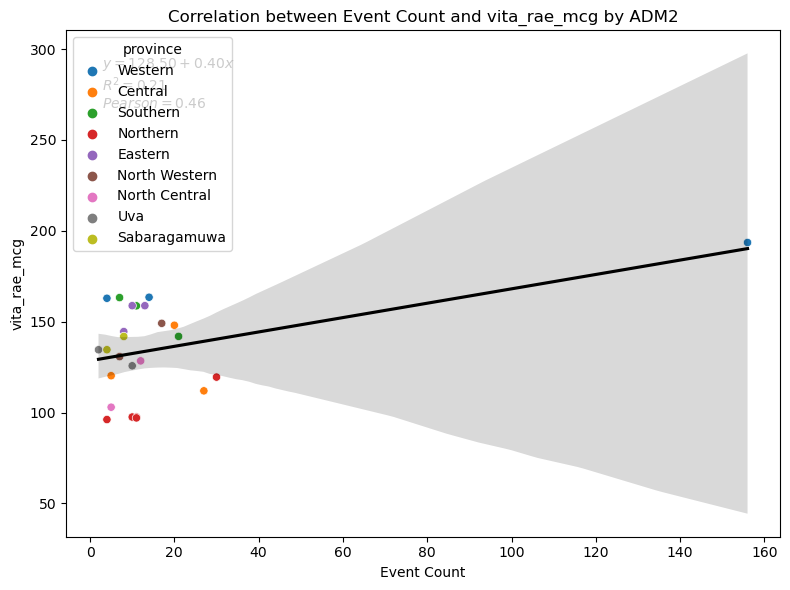

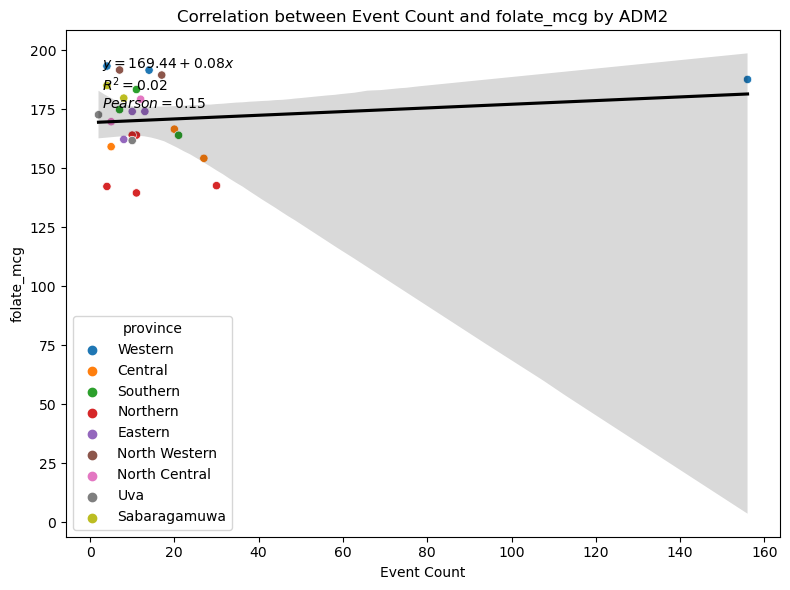

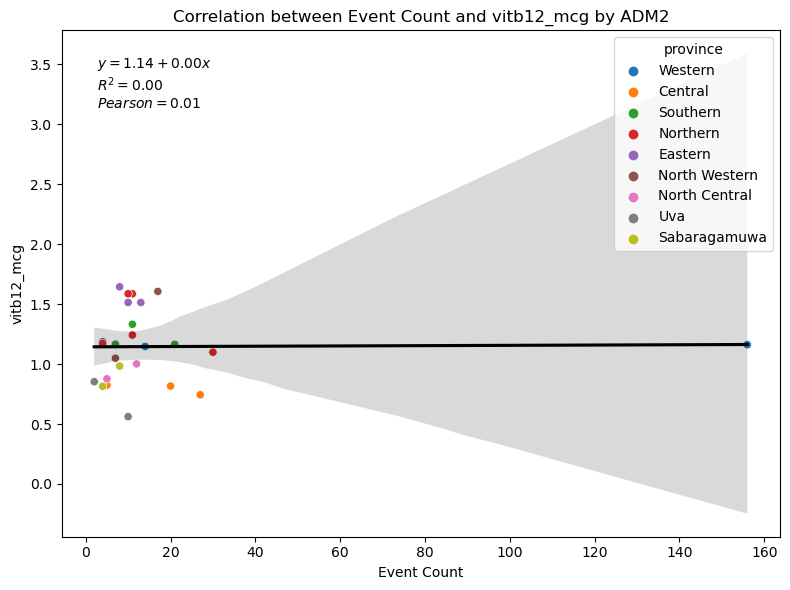

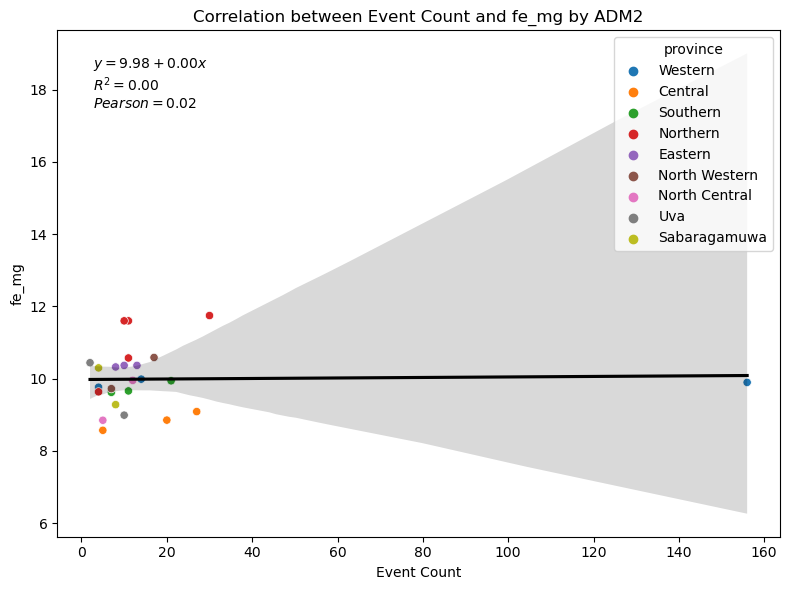

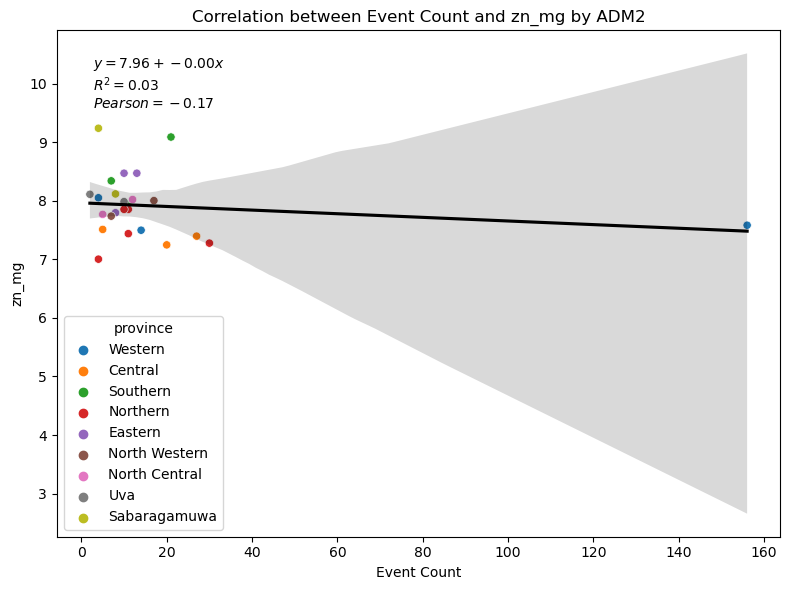

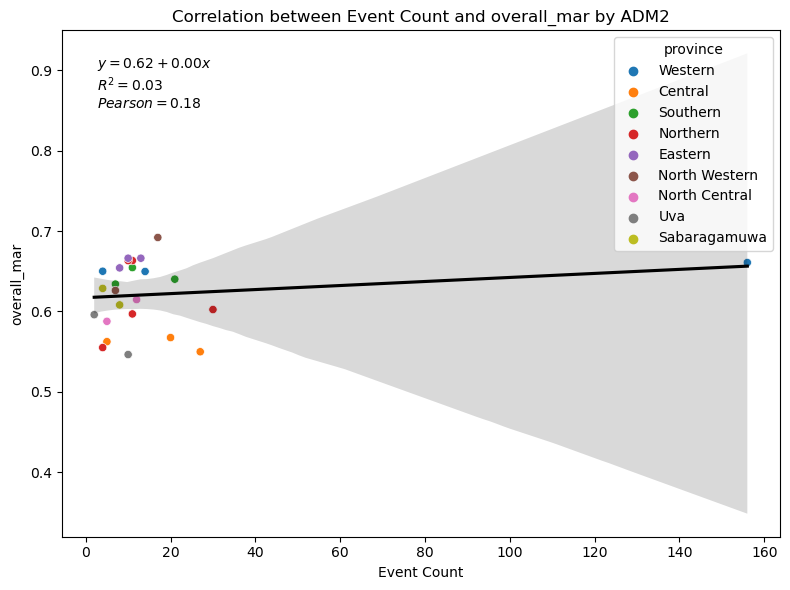

In [ ]:

# Merge the data
adm2_counts = adm2_season_hh[['hhid','adm2','vita_rae_mcg','folate_mcg','vitb12_mcg','fe_mg','zn_mg','overall_mar']] \
    .groupby('adm2').agg({
        'vita_rae_mcg':'median',
         'folate_mcg':'median',
         	'vitb12_mcg':'median',	'fe_mg':'median',	'zn_mg':'median',
            'overall_mar':'median'
    }).reset_index().merge(acled_counts2018_noseason, on='adm2')

# Pivot the data
province_map = {
    1: "Western", 2: "Central", 3: "Southern", 4: "Northern", 5: "Eastern",
    6: "North Western", 7: "North Central", 8: "Uva", 9: "Sabaragamuwa"
}
adm2_counts['province'] = (adm2_counts['adm2'] // 10).round().map(province_map)

mn_col_names = list(['vita_rae_mcg', 'folate_mcg', 'vitb12_mcg', 'fe_mg', 'zn_mg', 'overall_mar'])
for i in mn_col_names:

    X = sm.add_constant(adm2_counts['count'])
    y = adm2_counts[i]

    # Combine X and y into a single DataFrame for cleaning
    data = pd.concat([X, y], axis=1)

    # Remove rows with NaN or inf values
    data_clean = data.replace([np.inf, -np.inf], np.nan).dropna()

    # Separate cleaned X and y
    X_clean = data_clean.iloc[:, :-1]
    y_clean = data_clean.iloc[:, -1]

    # Fit the model
    model = sm.OLS(y_clean, X_clean).fit()

    r_squared = model.rsquared
    intercept, slope = model.params

    pearson_r = model.params[1] / abs(model.params[1]) * r_squared**0.5

    # Annotate with R² and equation
    eq_label = f"$y = {intercept:.2f} + {slope:.2f}x$\n$R^2 = {r_squared:.2f}$\n$Pearson = {pearson_r:.2f}$"

    plt.figure(figsize=(8,6))
    sns.scatterplot(data=adm2_counts, x='count', y=i, hue='province', )
    plt.text(0.05, 0.95, eq_label, transform=plt.gca().transAxes,
                 verticalalignment='top', horizontalalignment='left', fontsize=10)

    sns.regplot(data=adm2_counts, x='count', y=i, scatter=False, color='black')
    plt.title(f"Correlation between Event Count and {i} by ADM2")
    plt.xlabel("Event Count")
    plt.ylabel(f"{i}")
    plt.tight_layout()
    plt.show()

